# Change Detection на спутниковых снимках

## Описание проекта

Данный проект решает задачу обнаружения изменений на спутниковых изображениях.
Модель получает на вход два снимка одной и той же местности, сделанные в разное время, и предсказывает маску изменений — области, где произошли изменения (например, появление или исчезновение зданий).

## Получение файлов

In [1]:
import os
import glob

BASE_DIR = "./data/LEVIR-CD+"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

A_DIR = "A"
B_DIR = "B"
LABEL_DIR = "label"

In [2]:
def get_files(split_dir):
    images_A = sorted(glob.glob(os.path.join(split_dir, A_DIR, "*.png")))
    images_B = sorted(glob.glob(os.path.join(split_dir, B_DIR, "*.png")))
    labels = sorted(glob.glob(os.path.join(split_dir, LABEL_DIR, "*.png")))

    return images_A, images_B, labels

In [3]:
train_A, train_B, train_labels = get_files(TRAIN_DIR)
test_A, test_B, test_labels = get_files(TEST_DIR)

print("TRAIN:")
print(len(train_A), len(train_B), len(train_labels))

print("TEST:")
print(len(test_A), len(test_B), len(test_labels))

TRAIN:
637 637 637
TEST:
348 348 348


### Проверка чтения изображений

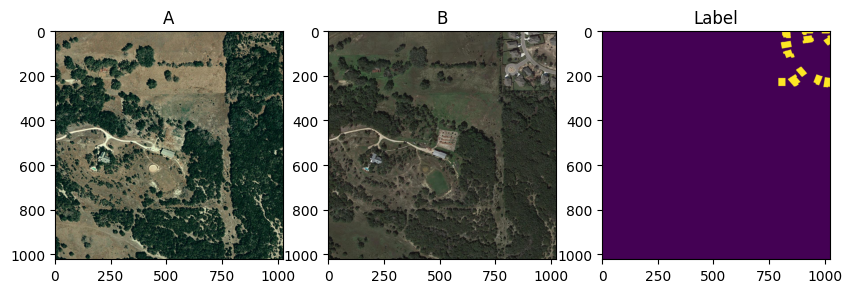

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

img_A = Image.open(train_A[0])
img_B = Image.open(train_B[0])
mask = Image.open(train_labels[0])

plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.title("A")
plt.imshow(img_A)

plt.subplot(1,3,2)
plt.title("B")
plt.imshow(img_B)

plt.subplot(1,3,3)
plt.title("Label")
plt.imshow(mask)

plt.show()

### Датасет

In [5]:
train_pairs = list(zip(train_A, train_B, train_labels))
test_pairs = list(zip(test_A, test_B, test_labels))

print("Train pairs:", len(train_pairs))

Train pairs: 637


In [6]:
import numpy as np
import torch
from torch.utils.data import Dataset

class LevirDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        path_A, path_B, path_mask = self.pairs[idx]

        img_A = np.array(Image.open(path_A).convert("RGB")) / 255.0
        img_B = np.array(Image.open(path_B).convert("RGB")) / 255.0
        mask = np.array(Image.open(path_mask).convert("L"))

        mask = (mask > 0).astype(np.float32)

        img = np.concatenate([img_A, img_B], axis=2)

        img = torch.tensor(img).permute(2, 0, 1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

torch.Size([6, 1024, 1024])
torch.Size([1, 1024, 1024])


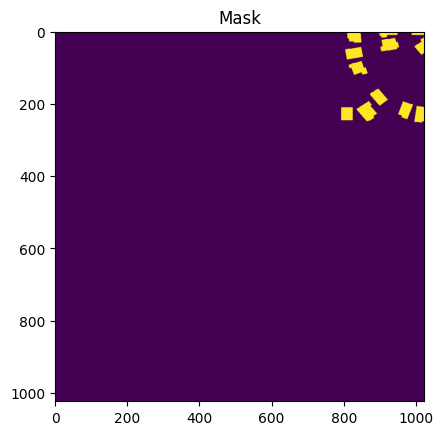

In [7]:
dataset = LevirDataset(train_pairs)

img, mask = dataset[0]

print(img.shape)
print(mask.shape)

plt.imshow(mask[0])
plt.title("Mask")
plt.show()

## Обучение на всех данных

### Импорт библиотек

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

### Пути к датасету

In [ ]:
BASE_DIR = "./data/LEVIR-CD+"

def get_pairs(base_dir, split="train"):
    A_dir = os.path.join(base_dir, split, "A")
    B_dir = os.path.join(base_dir, split, "B")
    L_dir = os.path.join(base_dir, split, "label")

    files = sorted(os.listdir(A_dir))

    pairs = []
    for f in files:
        pairs.append((
            os.path.join(A_dir, f),
            os.path.join(B_dir, f),
            os.path.join(L_dir, f)
        ))
    return pairs

train_pairs = get_pairs(BASE_DIR, "train")
test_pairs = get_pairs(BASE_DIR, "test")

print("Train:", len(train_pairs))
print("Test:", len(test_pairs))

### Датасет для бинарной классификации

Создает пользовательский датасет для задачи обнаружения изменений на спутниковых снимках (LEVIR-CD датасет), где нужно сравнить два изображения одного и того же района, сделанные в разное время, и выделить области, где произошли изменения.

In [ ]:
class LevirDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        path_A, path_B, path_mask = self.pairs[idx]

        img_A = np.array(Image.open(path_A).convert("RGB")) / 255.0
        img_B = np.array(Image.open(path_B).convert("RGB")) / 255.0
        mask = np.array(Image.open(path_mask).convert("L")) / 255.0

        mask = (mask > 0).astype(np.float32)

        # объединяем A и B → 6 каналов
        img = np.concatenate([img_A, img_B], axis=2)

        img = torch.tensor(img).permute(2, 0, 1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask


train_dataset = LevirDataset(train_pairs)
test_dataset = LevirDataset(test_pairs)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4)

### Архитектура Siamese U-Net для обнаружения изменений

Реализует специализированную нейронную сеть Siamese U-Net для задачи обнаружения изменений на паре спутниковых снимков (до/после). Сеть имеет две ветви-близнеца для обработки каждого изображения, а затем сравнивает их признаки для выявления изменений.

In [ ]:
class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU()
        )
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.conv(x)
        p = self.pool(x)
        return x, p


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x


class SiameseUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = EncoderBlock(3, 32)
        self.enc2 = EncoderBlock(32, 64)
        self.enc3 = EncoderBlock(64, 128)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU()
        )

        self.dec3 = DecoderBlock(256, 128)
        self.dec2 = DecoderBlock(128, 64)
        self.dec1 = DecoderBlock(64, 32)

        self.final = nn.Conv2d(32, 1, 1)

    def forward_once(self, x):
        x1, p1 = self.enc1(x)
        x2, p2 = self.enc2(p1)
        x3, p3 = self.enc3(p2)
        return x1, x2, x3, p3

    def forward(self, img):
        img_A = img[:, :3]
        img_B = img[:, 3:]

        A1, A2, A3, Ap = self.forward_once(img_A)
        B1, B2, B3, Bp = self.forward_once(img_B)

        x = torch.abs(Ap - Bp)
        x = self.bottleneck(x)

        x = self.dec3(x, torch.abs(A3 - B3))
        x = self.dec2(x, torch.abs(A2 - B2))
        x = self.dec1(x, torch.abs(A1 - B1))

        return self.final(x)

### Обучение

Так как обучение происходит долго, то для первичного теста было проведено обучение на 2 эпохах.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SiameseUNet().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 2

for epoch in range(epochs):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for imgs, masks in loop:
        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = model(imgs)
        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"\nEpoch {epoch+1}: Avg Loss = {total_loss / len(train_loader):.4f}")

### Сохранение модели

In [ ]:
torch.save(model.state_dict(), "siamese_unet_levir.pth")

print("Модель сохранена как siamese_unet_levir.pth")

## Визуализация

Загружается один тестовый пример из датасета, пропускается через обученную модель и визуализируется результат обнаружения между двумя спутниковыми снимками.

Train: 637
Test: 348


Epoch 1/2: 100%|█████████████████████████████████████████████████████████| 160/160 [52:30<00:00, 19.69s/it, loss=0.0839]



Epoch 1: Avg Loss = 0.2130


Epoch 2/2: 100%|████████████████████████████████████████████████████████| 160/160 [52:53<00:00, 19.84s/it, loss=0.00764]



Epoch 2: Avg Loss = 0.1388
Модель сохранена как siamese_unet_levir.pth


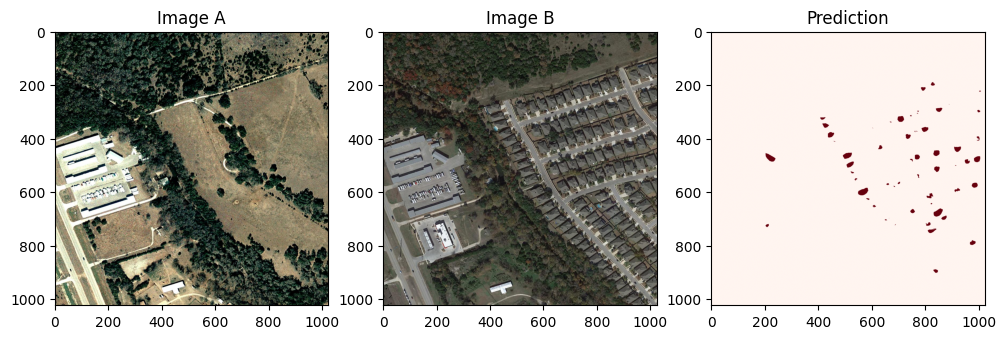

In [3]:
model.eval()

img, mask = test_dataset[0]

with torch.no_grad():
    pred = torch.sigmoid(model(img.unsqueeze(0).to(device)))[0,0].cpu()

img_A = img[:3].permute(1,2,0)
img_B = img[3:].permute(1,2,0)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image A")
plt.imshow(img_A)

plt.subplot(1,3,2)
plt.title("Image B")
plt.imshow(img_B)

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred > 0.5, cmap='Reds')

plt.show()


## Продолжение обучения и тестирование

### Тест

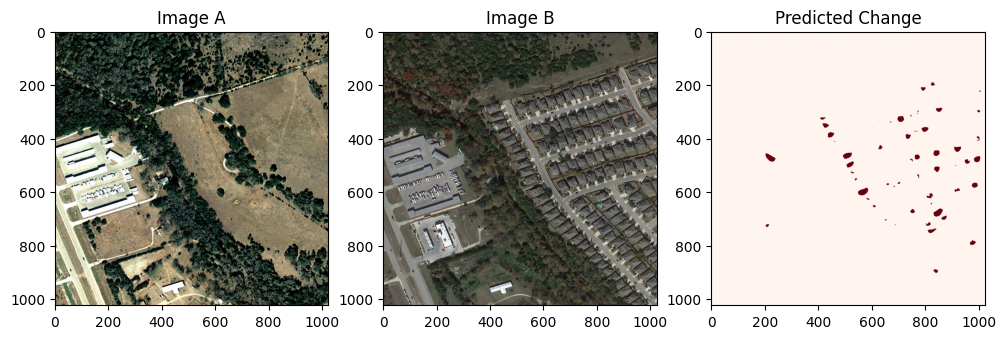

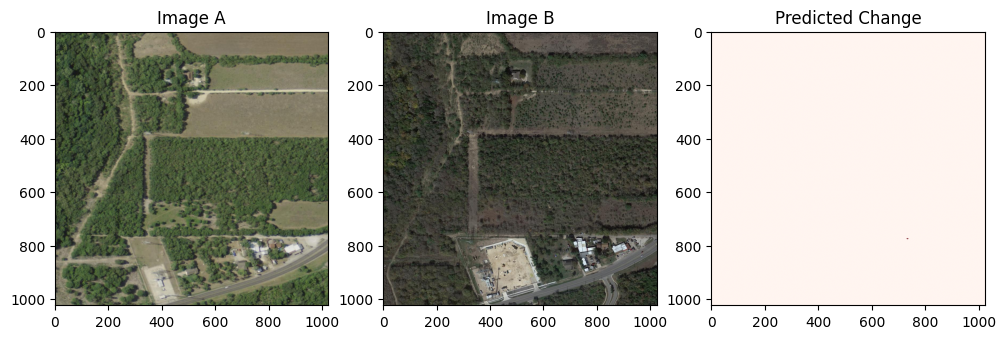

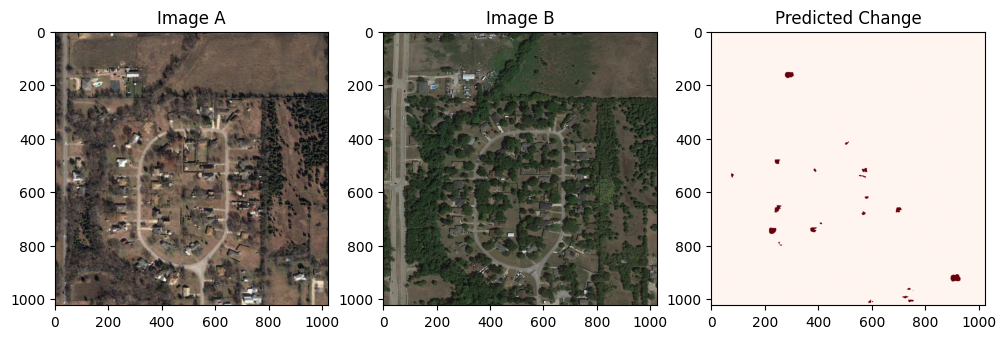

In [4]:
for i in range(3):
    img, mask = test_dataset[i]
    with torch.no_grad():
        pred = torch.sigmoid(model(img.unsqueeze(0).to(device)))[0,0].cpu()
    img_A = img[:3].permute(1,2,0)
    img_B = img[3:].permute(1,2,0)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.title("Image A")
    plt.imshow(img_A)

    plt.subplot(1,3,2)
    plt.title("Image B")
    plt.imshow(img_B)

    plt.subplot(1,3,3)
    plt.title("Predicted Change")
    plt.imshow(pred > 0.5, cmap='Reds')
    plt.show()

### Продолжение обучения с подгрузкой весов модели

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU()
        )
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.conv(x)
        p = self.pool(x)
        return x, p

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x

class SiameseUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = EncoderBlock(3, 32)
        self.enc2 = EncoderBlock(32, 64)
        self.enc3 = EncoderBlock(64, 128)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU()
        )

        self.dec3 = DecoderBlock(256, 128)
        self.dec2 = DecoderBlock(128, 64)
        self.dec1 = DecoderBlock(64, 32)

        self.final = nn.Conv2d(32, 1, 1)

    def forward_once(self, x):
        x1, p1 = self.enc1(x)
        x2, p2 = self.enc2(p1)
        x3, p3 = self.enc3(p2)
        return x1, x2, x3, p3

    def forward(self, img):
        img_A = img[:, :3]
        img_B = img[:, 3:]

        A1, A2, A3, Ap = self.forward_once(img_A)
        B1, B2, B3, Bp = self.forward_once(img_B)

        x = torch.abs(Ap - Bp)
        x = self.bottleneck(x)

        x = self.dec3(x, torch.abs(A3 - B3))
        x = self.dec2(x, torch.abs(A2 - B2))
        x = self.dec1(x, torch.abs(A1 - B1))

        return self.final(x)

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SiameseUNet().to(device)
model.load_state_dict(torch.load("siamese_unet_levir.pth", map_location=device))
print("Веса загружены, можно продолжать обучение")

Веса загружены, можно продолжать обучение


/tmp/ipykernel_573/1749476039.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("siamese_unet_levir.pth", map_location=device))


### Обучение на еще 2 эпохах

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

In [8]:
from tqdm import tqdm

epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch (continue) {epoch+1}/{epochs}")

    for imgs, masks in loop:
        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = model(imgs)
        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"\nEpoch {epoch+1} finished. Avg Loss = {total_loss / len(train_loader):.4f}")



Epoch (continue) 1/2: 100%|██████████████████████████████████████████████| 160/160 [52:45<00:00, 19.78s/it, loss=0.0217]



Epoch 1 finished. Avg Loss = 0.1146


Epoch (continue) 2/2: 100%|██████████████████████████████████████████████| 160/160 [57:06<00:00, 21.42s/it, loss=0.0899]


Epoch 2 finished. Avg Loss = 0.0969


In [9]:
torch.save(model.state_dict(), "siamese_unet_levir.pth")
print("Модель обновлена и сохранена снова")

Модель обновлена и сохранена снова


### Тест

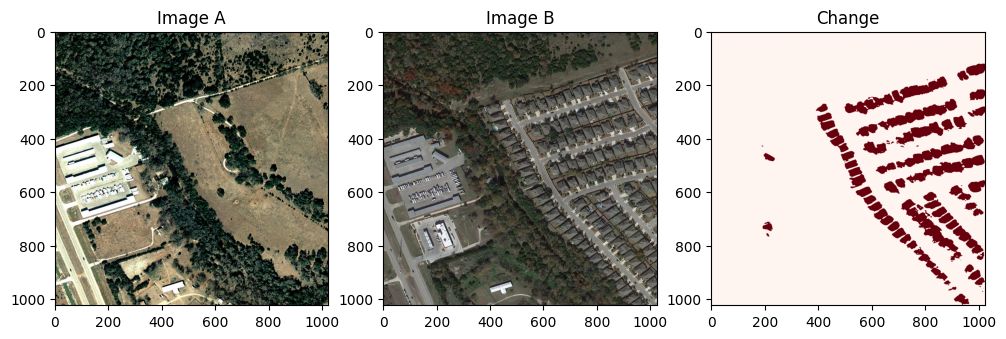

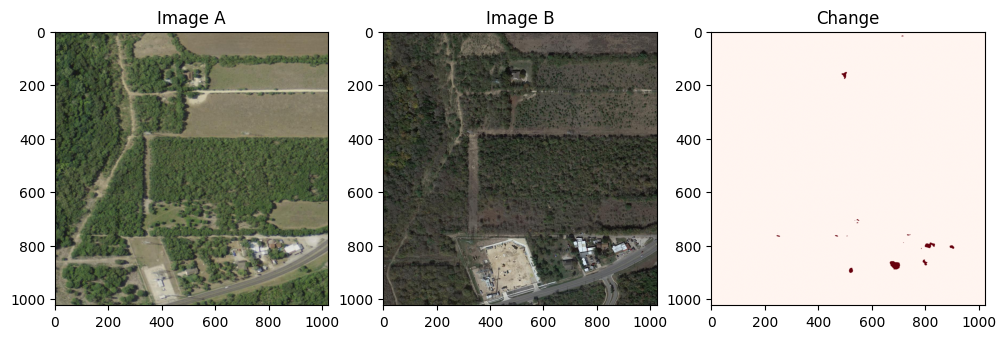

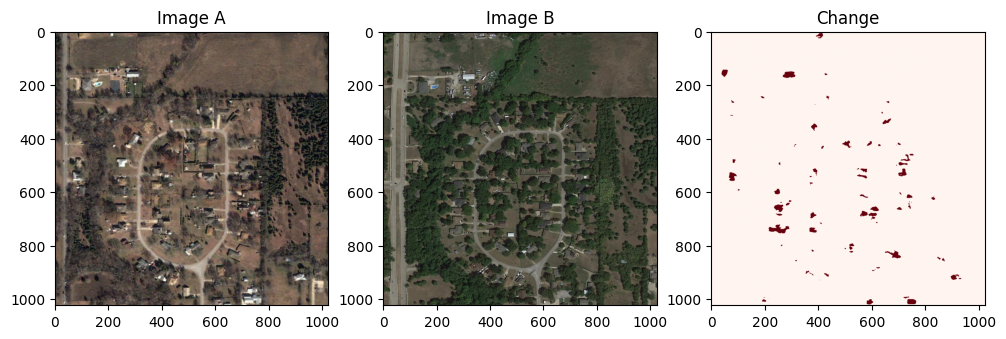

In [11]:
for i in range(3):
    img, mask = test_dataset[i]
    with torch.no_grad():
        pred = torch.sigmoid(model(img.unsqueeze(0).to(device)))[0,0].cpu()
    img_A = img[:3].permute(1,2,0)
    img_B = img[3:].permute(1,2,0)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.title("Image A")
    plt.imshow(img_A)

    plt.subplot(1,3,2)
    plt.title("Image B")
    plt.imshow(img_B)

    plt.subplot(1,3,3)
    plt.title("Change")
    plt.imshow(pred > 0.5, cmap='Reds')
    plt.show()

### Продолжение обучения

In [6]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

BASE_DIR = "./data/LEVIR-CD+"

def get_pairs(base_dir, split="train"):
    A_dir = os.path.join(base_dir, split, "A")
    B_dir = os.path.join(base_dir, split, "B")
    L_dir = os.path.join(base_dir, split, "label")

    files = sorted(os.listdir(A_dir))

    pairs = []
    for f in files:
        pairs.append((
            os.path.join(A_dir, f),
            os.path.join(B_dir, f),
            os.path.join(L_dir, f)
        ))
    return pairs

train_pairs = get_pairs(BASE_DIR, "train")
test_pairs = get_pairs(BASE_DIR, "test")

print("Train:", len(train_pairs))
print("Test:", len(test_pairs))

class LevirDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        path_A, path_B, path_mask = self.pairs[idx]

        img_A = np.array(Image.open(path_A).convert("RGB")) / 255.0
        img_B = np.array(Image.open(path_B).convert("RGB")) / 255.0
        mask = np.array(Image.open(path_mask).convert("L")) / 255.0

        mask = (mask > 0).astype(np.float32)

        img = np.concatenate([img_A, img_B], axis=2)

        img = torch.tensor(img).permute(2, 0, 1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask


train_dataset = LevirDataset(train_pairs)
test_dataset = LevirDataset(test_pairs)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4)

class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU()
        )
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.conv(x)
        p = self.pool(x)
        return x, p


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x


class SiameseUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = EncoderBlock(3, 32)
        self.enc2 = EncoderBlock(32, 64)
        self.enc3 = EncoderBlock(64, 128)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU()
        )

        self.dec3 = DecoderBlock(256, 128)
        self.dec2 = DecoderBlock(128, 64)
        self.dec1 = DecoderBlock(64, 32)

        self.final = nn.Conv2d(32, 1, 1)

    def forward_once(self, x):
        x1, p1 = self.enc1(x)
        x2, p2 = self.enc2(p1)
        x3, p3 = self.enc3(p2)
        return x1, x2, x3, p3

    def forward(self, img):
        img_A = img[:, :3]
        img_B = img[:, 3:]

        A1, A2, A3, Ap = self.forward_once(img_A)
        B1, B2, B3, Bp = self.forward_once(img_B)

        x = torch.abs(Ap - Bp)
        x = self.bottleneck(x)

        x = self.dec3(x, torch.abs(A3 - B3))
        x = self.dec2(x, torch.abs(A2 - B2))
        x = self.dec1(x, torch.abs(A1 - B1))

        return self.final(x)  # БЕЗ sigmoid!


Train: 637
Test: 348


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SiameseUNet().to(device)
model.load_state_dict(torch.load("siamese_unet_levir.pth", map_location=device))
print("Веса загружены, можно продолжать обучение")

Веса загружены, можно продолжать обучение


/tmp/ipykernel_2490/1749476039.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("siamese_unet_levir.pth", map_location=device))


In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

In [9]:
from tqdm import tqdm

epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch (continue) {epoch+1}/{epochs}")

    for imgs, masks in loop:
        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = model(imgs)
        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"\nEpoch {epoch+1} finished. Avg Loss = {total_loss / len(train_loader):.4f}")

torch.save(model.state_dict(), "siamese_unet_levir.pth")
print("Модель обновлена и сохранена снова")

Epoch (continue) 1/2: 100%|████████████████████████████████████████████| 160/160 [1:05:26<00:00, 24.54s/it, loss=0.0406]



Epoch 1 finished. Avg Loss = 0.0945


Epoch (continue) 2/2: 100%|███████████████████████████████████████████████| 160/160 [48:40<00:00, 18.25s/it, loss=0.159]


Epoch 2 finished. Avg Loss = 0.0759
Модель обновлена и сохранена снова


### Тест

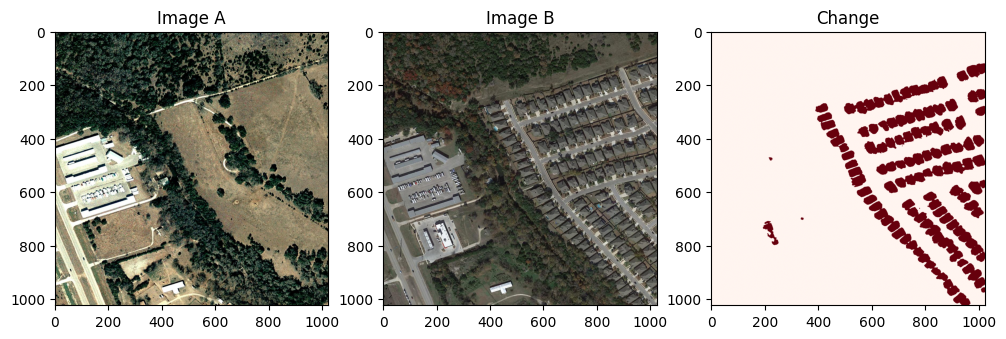

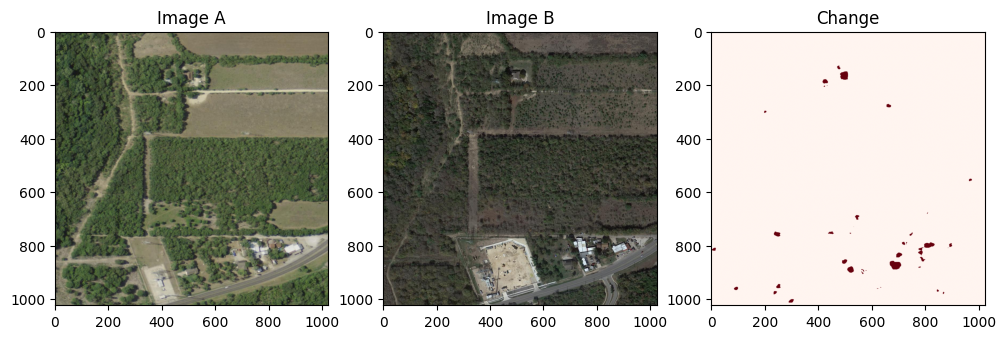

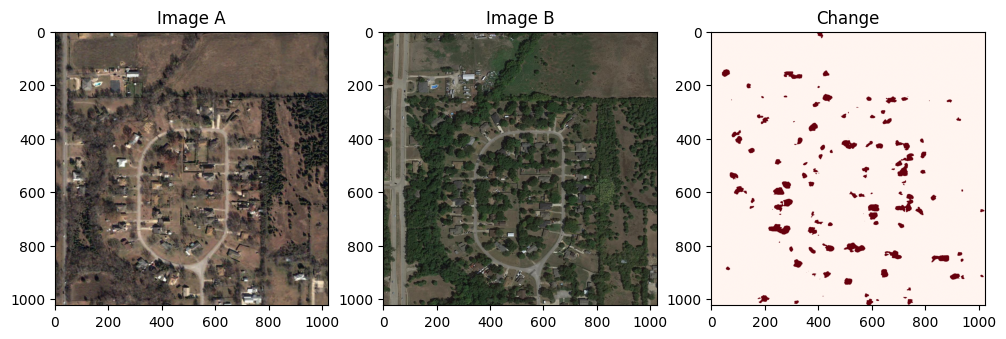

In [10]:
for i in range(3):
    img, mask = test_dataset[i]
    with torch.no_grad():
        pred = torch.sigmoid(model(img.unsqueeze(0).to(device)))[0,0].cpu()
    img_A = img[:3].permute(1,2,0)
    img_B = img[3:].permute(1,2,0)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.title("Image A")
    plt.imshow(img_A)

    plt.subplot(1,3,2)
    plt.title("Image B")
    plt.imshow(img_B)

    plt.subplot(1,3,3)
    plt.title("Change")
    plt.imshow(pred > 0.5, cmap='Reds')
    plt.show()

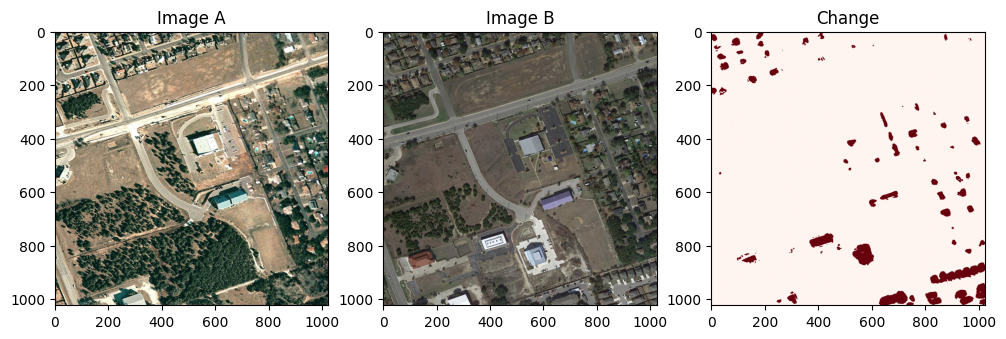

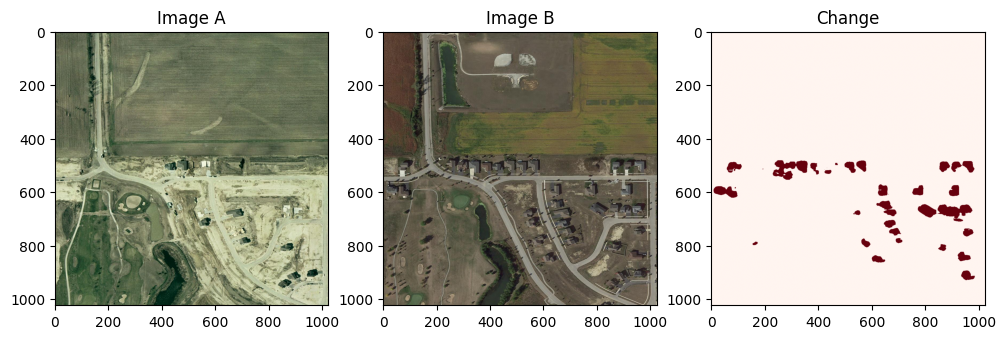

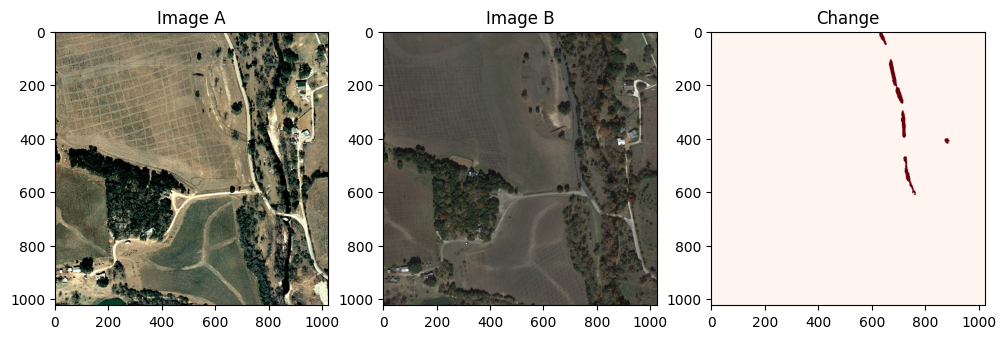

In [12]:
for i in range(3, 6):
    img, mask = test_dataset[i]
    with torch.no_grad():
        pred = torch.sigmoid(model(img.unsqueeze(0).to(device)))[0,0].cpu()
    img_A = img[:3].permute(1,2,0)
    img_B = img[3:].permute(1,2,0)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.title("Image A")
    plt.imshow(img_A)

    plt.subplot(1,3,2)
    plt.title("Image B")
    plt.imshow(img_B)

    plt.subplot(1,3,3)
    plt.title("Change")
    plt.imshow(pred > 0.5, cmap='Reds')
    plt.show()